In [11]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [12]:
df=pd.read_excel('nike_data.xlsx')

In [13]:
print(df.head())

   ↑                       Unnamed: 1  \
0  1             Nike Air Force 1 '01   
1  2             Nike Air Force 1 '07   
2  3          Nike Air Force 1 Shadow   
3  4  Nike Air Force 1 Tech Essential   
4  5      Nike Air Force 1 '07 EasyOn   

                                          Unnamed: 2  \
0                    nike.com/fr/launch/r/IV4501-100   
1  nike.com/fr/t/chaussure-nike-air-force-1-07-po...   
2  nike.com/fr/t/chaussure-nike-air-force-1-shado...   
3  nike.com/fr/t/chaussure-nike-air-force-1-tech-...   
4  nike.com/fr/t/chaussure-nike-air-force-1-07-ea...   

                                          Unnamed: 3 Unnamed: 4  \
0          Nike Air Force 1 '01 Chaussure pour homme   139,99 €   
1          Nike Air Force 1 '07 Chaussure pour homme   119,99 €   
2       Nike Air Force 1 Shadow Chaussure pour Femme   129,99 €   
3  Nike Air Force 1 Tech Essential Chaussure pour...    99,99 €   
4   Nike Air Force 1 '07 EasyOn Chaussure pour femme   119,99 €   

             

In [14]:
new_columns = [
    'ID_Produit',
    'Nom_Produit_1',
    'Lien_Produit_1',
    'Description_1',
    'Prix',
    'Lien_Couleur_1',
    'Couleur_1',
    'Lien_Couleur_2',
    'Couleur_2',
    'Nom_Produit_2',
    'Description_2',
    'Lien_Produit_2',
    'Categorie_Genre',
    'Option_1',
    'Option_2',
    'Lien_Option',
    'Couleur_3',
    'Details_Supplementaires']

df.columns = new_columns

In [15]:
print(df.dtypes)

ID_Produit                  int64
Nom_Produit_1              object
Lien_Produit_1             object
Description_1              object
Prix                       object
Lien_Couleur_1             object
Couleur_1                  object
Lien_Couleur_2             object
Couleur_2                  object
Nom_Produit_2              object
Description_2              object
Lien_Produit_2             object
Categorie_Genre            object
Option_1                   object
Option_2                   object
Lien_Option                object
Couleur_3                  object
Details_Supplementaires    object
dtype: object


In [16]:
for col in df.columns:
    if df[col].astype(str).str.contains('€').any():
        df[col] = df[col].astype(str).str.replace('€', '', regex=False)
        df[col] = df[col].str.replace('\xa0', '', regex=True)
        df[col] = df[col].str.replace(',', '.', regex=False)
        df[col] = df[col].str.strip()
        df[col] = pd.to_numeric(df[col], errors='coerce')
        df.rename(columns={col: 'Prix'}, inplace=True)

In [18]:
print(df['Prix'].head())

0    139.99
1    119.99
2    129.99
3     99.99
4    119.99
Name: Prix, dtype: float64


In [19]:
df.replace('—', np.nan, inplace=True)

In [20]:
print(df.isnull().sum())

ID_Produit                  0
Nom_Produit_1               0
Lien_Produit_1              0
Description_1               0
Prix                        0
Lien_Couleur_1             37
Couleur_1                  37
Lien_Couleur_2             37
Couleur_2                  37
Nom_Produit_2              37
Description_2              37
Lien_Produit_2             58
Categorie_Genre            58
Option_1                   60
Option_2                   60
Lien_Option                60
Couleur_3                  66
Details_Supplementaires    66
dtype: int64


In [21]:
print(df['Prix'].describe())

count     96.000000
mean     126.760833
std       23.747124
min       59.990000
25%      119.990000
50%      129.990000
75%      129.990000
max      199.990000
Name: Prix, dtype: float64


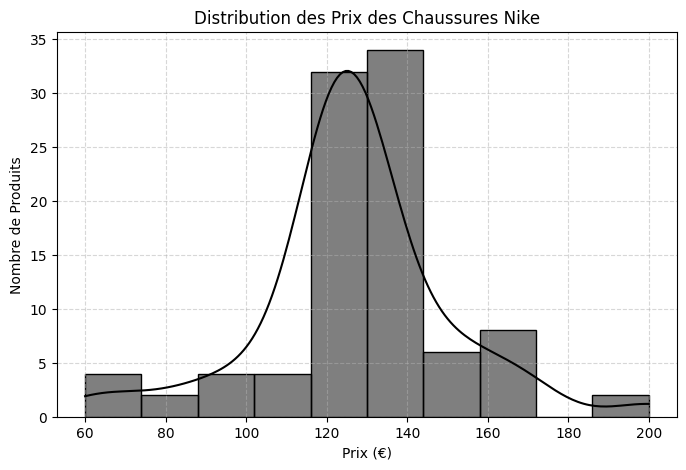

In [22]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Prix'], bins=10, kde=True, color='black')
plt.title('Distribution des Prix des Chaussures Nike')
plt.xlabel('Prix (€)')
plt.ylabel('Nombre de Produits')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [23]:
df.fillna('Aucun', inplace=True)
print(df.isnull().sum())

ID_Produit                 0
Nom_Produit_1              0
Lien_Produit_1             0
Description_1              0
Prix                       0
Lien_Couleur_1             0
Couleur_1                  0
Lien_Couleur_2             0
Couleur_2                  0
Nom_Produit_2              0
Description_2              0
Lien_Produit_2             0
Categorie_Genre            0
Option_1                   0
Option_2                   0
Lien_Option                0
Couleur_3                  0
Details_Supplementaires    0
dtype: int64


In [28]:
color_cols= ['Couleur_1', 'Couleur_2', 'Couleur_3']

In [29]:
df['Nombre_Couleurs'] = df[color_cols].apply(lambda row: sum([1 for c in row if c not in ['N/A', '', None]]), axis=1)

In [31]:
def combine_colors(row):
    colors = [str(row[c]) for c in color_cols if row[c] not in ['N/A', '', None]]
    return ", ".join(colors) if colors else "N/A"

In [32]:
df['Toutes_Les_Couleurs'] = df.apply(combine_colors, axis=1)

In [33]:
print(df[['Nom_Produit_1', 'Nombre_Couleurs', 'Toutes_Les_Couleurs', 'Prix']].head(5))

                     Nom_Produit_1  Nombre_Couleurs  \
0             Nike Air Force 1 '01                3   
1             Nike Air Force 1 '07                3   
2          Nike Air Force 1 Shadow                3   
3  Nike Air Force 1 Tech Essential                3   
4      Nike Air Force 1 '07 EasyOn                3   

                                 Toutes_Les_Couleurs    Prix  
0                                Aucun, Aucun, Aucun  139.99  
1  Blanc/Blanc, Blanc/Noir, nike.com/fr/t/chaussu...  119.99  
2                                Aucun, Aucun, Aucun  129.99  
3  Tarp Green/Metallic Silver/Light Menta/Light A...   99.99  
4                                Aucun, Aucun, Aucun  119.99  


In [34]:
df.drop(columns=['Couleur_1', 'Couleur_2', 'Couleur_3'], inplace=True)

In [36]:
print(df.dtypes)

ID_Produit                   int64
Nom_Produit_1               object
Lien_Produit_1              object
Description_1               object
Prix                       float64
Lien_Couleur_1              object
Lien_Couleur_2              object
Nom_Produit_2               object
Description_2               object
Lien_Produit_2              object
Categorie_Genre             object
Option_1                    object
Option_2                    object
Lien_Option                 object
Details_Supplementaires     object
Nombre_Couleurs              int64
Toutes_Les_Couleurs         object
dtype: object


In [37]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID_Produit               96 non-null     int64  
 1   Nom_Produit_1            96 non-null     object 
 2   Lien_Produit_1           96 non-null     object 
 3   Description_1            96 non-null     object 
 4   Prix                     96 non-null     float64
 5   Lien_Couleur_1           96 non-null     object 
 6   Lien_Couleur_2           96 non-null     object 
 7   Nom_Produit_2            96 non-null     object 
 8   Description_2            96 non-null     object 
 9   Lien_Produit_2           96 non-null     object 
 10  Categorie_Genre          96 non-null     object 
 11  Option_1                 96 non-null     object 
 12  Option_2                 96 non-null     object 
 13  Lien_Option              96 non-null     object 
 14  Details_Supplementaires  96 

In [38]:
df.to_csv('nike_data_final_ready.csv', index=False)